In [6]:
from dotenv import load_dotenv

load_dotenv()


True

In [7]:
from langchain_openai import ChatOpenAI

query = "What is the capital of France?"

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

llm.invoke(query)


AIMessage(content='The capital of France is Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3683ee3deb', 'id': 'chatcmpl-D3BnbJgv5Khdaab7O6JEimN6GkFwM', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c0785-6bd7-7041-a137-fecf7d3e8d14-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

# state, node, Edge, conditional Edge

state : 상태 -> 현재 Agent의 상태

node : Agent가 수행하는 작업
        혹은 함수

edge: 노드들을 사이의 관계, 노드연결

conditional Edge : 조건부 엣지



In [8]:
!uv add langgraph







Resolved 73 packages in 205ms                                        
⠙ Preparing packages... (0/6)                                                   
⠙ Preparing packages... (0/6)-------------------     0 B/45.24 KiB           
⠙ Preparing packages... (0/6)-------------------     0 B/45.24 KiB           
langgraph-checkpoint ------------------------------     0 B/45.24 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/65.45 KiB           
langgraph-checkpoint ------------------------------ 14.90 KiB/45.24 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/65.45 KiB           
langgraph-checkpoint ------------------------------ 14.90 KiB/45.24 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/65.45 KiB           
langgraph-checkpoint ------------------------------ 14.90 KiB/45.24 KiB
⠙ Preparing packages... (0/6)-------------------     0 B/65.45 KiB           
langgraph-checkpoint ------------------------------ 14.90 KiB/45.24 KiB
langgraph-sdk        --

In [ ]:
#state
from typing import Annotated # System Message, Human Message, AI Message
from typing_extensions import TypedDict  #dictionary 형태

from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]] 


In [ ]:
#graph
from langgraph.graph import StateGraph

graph_builder = StateGraph(AgentState)

In [12]:
def generate(state: AgentState) -> AgentState:
    messages = state["messages"]
    ai_message = llm.invoke(messages)
    return {"messages": [ai_message]}

In [13]:
#Edge
from langgraph.graph import START, END

graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

In [14]:
graph = graph_builder.compile()

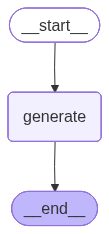

In [15]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [16]:
from langchain_core.messages import HumanMessage

initial_state = {"messages": [HumanMessage(query)]}

graph.invoke(initial_state)





{'messages': [AIMessage(content='The capital of France is Paris.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 7, 'prompt_tokens': 14, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3683ee3deb', 'id': 'chatcmpl-D3C37oHrMza9xFZCayi1NPQulQ8hW', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c0794-1764-7913-9e9d-d782b1ad8ff9-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 7, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}